<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/programacion_dinamica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Programación Dinámica

## 🎯 Objetivos

Al finalizar este material, deberías poder:

- comprender qué es la **programación dinámica**;
- identificar cuándo un problema presenta:
  - **subestructura óptima**;
  - **subproblemas traslapados**;
- distinguir entre:
  - solución recursiva ingenua;
  - enfoque **top-down con memoización**;
  - enfoque **bottom-up con tabulación**;
- observar experimentalmente la mejora de rendimiento que aporta la programación dinámica;
- aplicar estos conceptos al problema clásico de **Fibonacci** y al problema de **corte de varillas**.


In [ ]:
import time
import math
import matplotlib.pyplot as plt
from functools import lru_cache


## 🧠 Idea central

La **programación dinámica** es una técnica de diseño de algoritmos que busca evitar trabajo repetido al resolver subproblemas una sola vez y reutilizar sus resultados.

Generalmente aparece cuando:

1. el problema puede descomponerse en subproblemas más pequeños;
2. esos subproblemas se repiten muchas veces;
3. existe una forma de construir una solución óptima a partir de soluciones óptimas de subproblemas.

## Dos formas comunes de Programación Dinámica

### 1. Top-Down (memoización)
- parte de la solución recursiva;
- guarda resultados ya calculados;
- evita recalcular subproblemas.

### 2. Bottom-Up (tabulación)
- resuelve primero los casos más pequeños;
- construye progresivamente la solución;
- normalmente se implementa de forma iterativa.


# 1. Ejemplo introductorio: Fibonacci

Usaremos Fibonacci como primer ejemplo porque permite ver muy claramente el problema de los **subproblemas traslapados**.

La definición clásica es:

\[
F(n)=F(n-1)+F(n-2)
\]

con casos base:

\[
F(0)=0, \quad F(1)=1
\]


## 1.1 Fibonacci recursivo ingenuo


In [ ]:
def fib_recursivo(n):
    if n < 0:
        raise ValueError("n debe ser >= 0")
    if n <= 1:
        return n
    return fib_recursivo(n - 1) + fib_recursivo(n - 2)


## 1.2 Fibonacci con Programación Dinámica (top-down con memoización)


In [ ]:
@lru_cache(maxsize=None)
def fib_memo(n):
    if n < 0:
        raise ValueError("n debe ser >= 0")
    if n <= 1:
        return n
    return fib_memo(n - 1) + fib_memo(n - 2)


## 1.3 Fibonacci con Programación Dinámica (bottom-up)


In [ ]:
def fib_bottom_up(n):
    if n < 0:
        raise ValueError("n debe ser >= 0")
    if n <= 1:
        return n

    dp = [0] * (n + 1)
    dp[1] = 1

    for i in range(2, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2]

    return dp[n]


## 1.4 Validación rápida


In [ ]:
for n in range(11):
    print(n, fib_recursivo(n), fib_memo(n), fib_bottom_up(n))


0 0 0 0
1 1 1 1
2 1 1 1
3 2 2 2
4 3 3 3
5 5 5 5
6 8 8 8
7 13 13 13
8 21 21 21
9 34 34 34
10 55 55 55


## 1.5 Medición experimental de rendimiento en Fibonacci

Compararemos:
- recursivo ingenuo,
- top-down con memoización,
- bottom-up con tabulación.

⚠️ La versión recursiva ingenua crece muy rápido, así que usaremos valores pequeños para ella.


In [ ]:
def medir_tiempo(func, *args, repeticiones=1):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        func(*args)
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    return sum(tiempos) / len(tiempos)


In [ ]:
ns_fib_naive = list(range(0, 36, 2))
tiempos_fib_naive = [medir_tiempo(fib_recursivo, n) for n in ns_fib_naive]

fib_memo.cache_clear()

ns_fib_pd = list(range(0, 501, 25))
tiempos_fib_memo = []
tiempos_fib_bottom = []

for n in ns_fib_pd:
    fib_memo.cache_clear()
    tiempos_fib_memo.append(medir_tiempo(fib_memo, n))
    tiempos_fib_bottom.append(medir_tiempo(fib_bottom_up, n))


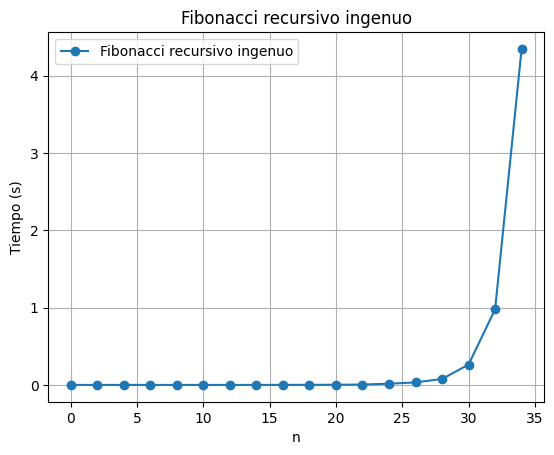

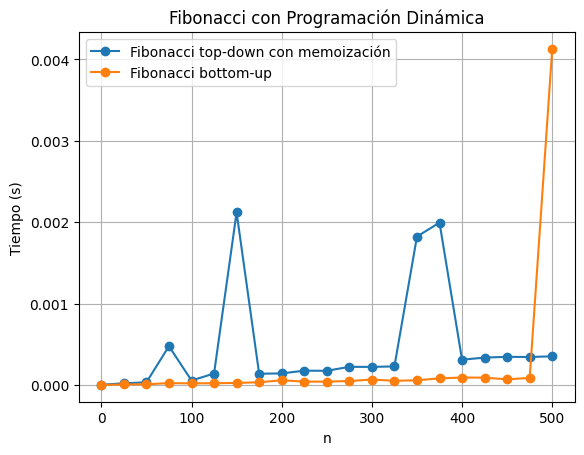

In [ ]:
plt.figure()
plt.plot(ns_fib_naive, tiempos_fib_naive, marker="o", label="Fibonacci recursivo ingenuo")
plt.xlabel("n")
plt.ylabel("Tiempo (s)")
plt.title("Fibonacci recursivo ingenuo")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(ns_fib_pd, tiempos_fib_memo, marker="o", label="Fibonacci top-down con memoización")
plt.plot(ns_fib_pd, tiempos_fib_bottom, marker="o", label="Fibonacci bottom-up")
plt.xlabel("n")
plt.ylabel("Tiempo (s)")
plt.title("Fibonacci con Programación Dinámica")
plt.grid(True)
plt.legend()
plt.show()


## 1.6 Interpretación

### Fibonacci recursivo ingenuo
- recalcula múltiples veces los mismos subproblemas;
- el número de llamadas crece muy rápido;
- es un ejemplo clásico de solución ineficiente.

### Fibonacci con memoización
- cada subproblema se resuelve una sola vez;
- después se reutiliza el resultado;
- reduce drásticamente el trabajo repetido.

### Fibonacci bottom-up
- también evita recomputación;
- suele ser muy eficiente porque elimina el costo de las llamadas recursivas repetidas.


# 2. Problema de cortar varillas

Dada una varilla de longitud `n` y una tabla de precios `p[i]` que indica cuánto vale vender una pieza de longitud `i`, queremos determinar el **máximo ingreso posible** al cortar la varilla y vender sus partes.

La varilla puede:
- venderse completa;
- o dividirse en varias piezas.

El objetivo es encontrar la mejor combinación de cortes.

## Propiedades del problema

### Subestructura óptima
La mejor solución para una varilla de longitud `n` puede construirse a partir de mejores soluciones para longitudes menores.

### Subproblemas traslapados
Al evaluar distintas maneras de cortar la varilla, se repiten una y otra vez los mismos subproblemas.


## 2.1 Tabla de precios de ejemplo


In [ ]:
prices = [0, 1, 5, 8, 9, 10, 17, 17, 20, 24, 30]
print("Tabla de precios:", prices)


Tabla de precios: [0, 1, 5, 8, 9, 10, 17, 17, 20, 24, 30]


# 3. Corte de varillas: versión recursiva sin Programación Dinámica

La idea recursiva es:

\[
r(n) = \max_{1 \le i \le n} \{ p[i] + r(n-i) \}
\]

con:

\[
r(0)=0
\]


In [ ]:
def cut_rod_recursivo(prices, n):
    if n == 0:
        return 0

    q = -float("inf")
    for i in range(1, n + 1):
        q = max(q, prices[i] + cut_rod_recursivo(prices, n - i))
    return q


# 4. Corte de varillas: top-down con memoización


In [ ]:
def cut_rod_top_down(prices, n):
    memo = [-float("inf")] * (n + 1)

    def aux(m):
        if memo[m] >= 0:
            return memo[m]
        if m == 0:
            q = 0
        else:
            q = -float("inf")
            for i in range(1, m + 1):
                q = max(q, prices[i] + aux(m - i))
        memo[m] = q
        return q

    return aux(n)


# 5. Corte de varillas: bottom-up con tabulación


In [ ]:
def cut_rod_bottom_up(prices, n):
    dp = [0] * (n + 1)

    for j in range(1, n + 1):
        q = -float("inf")
        for i in range(1, j + 1):
            q = max(q, prices[i] + dp[j - i])
        dp[j] = q

    return dp[n]


# 6. Corte de varillas: versión iterativa con recuperación de cortes

Esta versión también es bottom-up, pero además recupera **qué cortes** producen la mejor ganancia.


In [ ]:
def cut_rod_bottom_up_with_solution(prices, n):
    dp = [0] * (n + 1)
    first_cut = [0] * (n + 1)

    for j in range(1, n + 1):
        q = -float("inf")
        best_cut = 0
        for i in range(1, j + 1):
            value = prices[i] + dp[j - i]
            if value > q:
                q = value
                best_cut = i
        dp[j] = q
        first_cut[j] = best_cut

    cuts = []
    length = n
    while length > 0:
        cuts.append(first_cut[length])
        length -= first_cut[length]

    return dp[n], cuts


## 6.1 Validación de resultados


In [ ]:
for n in range(1, 11):
    r1 = cut_rod_recursivo(prices, n)
    r2 = cut_rod_top_down(prices, n)
    r3 = cut_rod_bottom_up(prices, n)
    r4, cuts = cut_rod_bottom_up_with_solution(prices, n)
    print(f"n={n:2d} | rec={r1:2d} | top-down={r2:2d} | bottom-up={r3:2d} | solución={r4:2d}, cortes={cuts}")


n= 1 | rec= 1 | top-down= 1 | bottom-up= 1 | solución= 1, cortes=[1]
n= 2 | rec= 5 | top-down= 5 | bottom-up= 5 | solución= 5, cortes=[2]
n= 3 | rec= 8 | top-down= 8 | bottom-up= 8 | solución= 8, cortes=[3]
n= 4 | rec=10 | top-down=10 | bottom-up=10 | solución=10, cortes=[2, 2]
n= 5 | rec=13 | top-down=13 | bottom-up=13 | solución=13, cortes=[2, 3]
n= 6 | rec=17 | top-down=17 | bottom-up=17 | solución=17, cortes=[6]
n= 7 | rec=18 | top-down=18 | bottom-up=18 | solución=18, cortes=[1, 6]
n= 8 | rec=22 | top-down=22 | bottom-up=22 | solución=22, cortes=[2, 6]
n= 9 | rec=25 | top-down=25 | bottom-up=25 | solución=25, cortes=[3, 6]
n=10 | rec=30 | top-down=30 | bottom-up=30 | solución=30, cortes=[10]


# 7. Demostración experimental de rendimiento en corte de varillas

Ahora compararemos:

1. versión recursiva sin PD;
2. top-down con memoización;
3. bottom-up con tabulación.


In [ ]:
ns_rod_naive = list(range(1, len(prices)))
tiempos_rod_naive = [medir_tiempo(cut_rod_recursivo, prices, n) for n in ns_rod_naive]

ns_rod_pd = list(range(1, len(prices)))
tiempos_rod_top = [medir_tiempo(cut_rod_top_down, prices, n) for n in ns_rod_pd]
tiempos_rod_bottom = [medir_tiempo(cut_rod_bottom_up, prices, n) for n in ns_rod_pd]


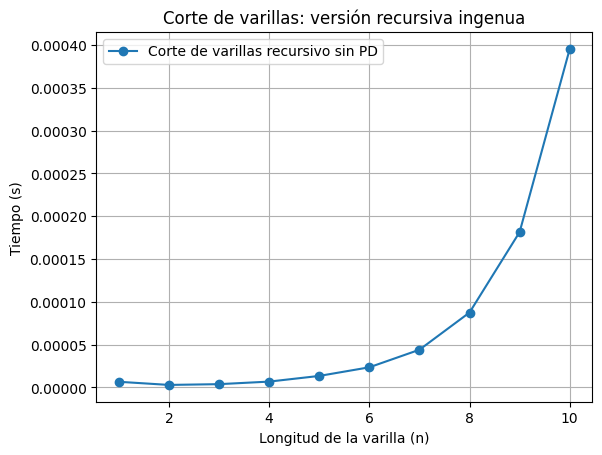

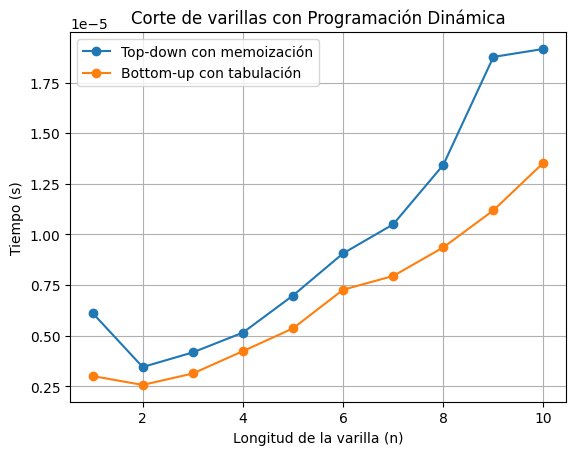

In [ ]:
plt.figure()
plt.plot(ns_rod_naive, tiempos_rod_naive, marker="o", label="Corte de varillas recursivo sin PD")
plt.xlabel("Longitud de la varilla (n)")
plt.ylabel("Tiempo (s)")
plt.title("Corte de varillas: versión recursiva ingenua")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(ns_rod_pd, tiempos_rod_top, marker="o", label="Top-down con memoización")
plt.plot(ns_rod_pd, tiempos_rod_bottom, marker="o", label="Bottom-up con tabulación")
plt.xlabel("Longitud de la varilla (n)")
plt.ylabel("Tiempo (s)")
plt.title("Corte de varillas con Programación Dinámica")
plt.grid(True)
plt.legend()
plt.show()


# 8. Visualización de la solución óptima en corte de varillas

Veamos algunos ejemplos de cortes óptimos.


In [ ]:
for n in range(1, 11):
    best_value, cuts = cut_rod_bottom_up_with_solution(prices, n)
    print(f"Longitud {n}: mejor ingreso = {best_value}, cortes = {cuts}")


Longitud 1: mejor ingreso = 1, cortes = [1]
Longitud 2: mejor ingreso = 5, cortes = [2]
Longitud 3: mejor ingreso = 8, cortes = [3]
Longitud 4: mejor ingreso = 10, cortes = [2, 2]
Longitud 5: mejor ingreso = 13, cortes = [2, 3]
Longitud 6: mejor ingreso = 17, cortes = [6]
Longitud 7: mejor ingreso = 18, cortes = [1, 6]
Longitud 8: mejor ingreso = 22, cortes = [2, 6]
Longitud 9: mejor ingreso = 25, cortes = [3, 6]
Longitud 10: mejor ingreso = 30, cortes = [10]


# 9. Resumen conceptual

## Recursivo sin PD
- resuelve correctamente el problema;
- pero repite muchos subproblemas;
- su rendimiento empeora rápidamente.

## Top-Down con memoización
- mantiene la idea recursiva original;
- evita recomputación guardando resultados;
- suele ser una transición natural desde la solución ingenua.

## Bottom-Up con tabulación
- elimina la necesidad de expandir recursivamente el árbol de llamadas;
- construye la solución desde los casos más pequeños;
- suele ser muy eficiente y claro para análisis.


# 10. Conclusión

La programación dinámica no es simplemente “hacer recursión”.

Su verdadera idea es:
- identificar subproblemas repetidos;
- resolverlos una sola vez;
- y reutilizar sus resultados de forma sistemática.

Con **Fibonacci** se entiende el principio básico.  
Con **corte de varillas** se observa cómo la técnica se aplica a un problema de optimización más explicito y representativo.
